##  Final Project
- Bruna

- Gabriel Moterani

- Maryam Wasif

```
# COSC5806003 - Data Analysis with Python
# Dr. Ping Luo
# Algoma University
# Department of Computer Science and Mathematics
# Brampton, Ontario, Canada
# Date: 04/15/2025
```


In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC # Program that calculates SVM (Support Vector Machine)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB # Program that calculates naive_bayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, classification_report
from sklearn.base import clone
from sklearn.pipeline import Pipeline

### Part 1: Choose a dataset (2 points)
1. Select any dataset from sources like: Kaggle, UCI Machine Learning Repository, etc.
The dataset must contain both categorical and numerical features and should have at least 500 samples (rows).
-> This dataset classifies people described by a set of attributes as good or bad credit risks. https://www.openml.org/search?type=data&sort=runs&id=31&status=active
2. You must explain why you chose this dataset and what questions you want to
answer.

In [2]:
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
X, y = data.data, data.target
df

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,none,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,<0,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,none,...,life insurance,40,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,no checking,12,existing paid,radio/tv,804,<100,>=7,4,male single,none,...,car,38,none,own,1,skilled,1,none,yes,good
998,<0,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,none,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


### Part 2: Exploratory Data Analysis (8 points)
1. Provide a summary of the dataset: Number of rows, columns, data types, missing
values.
2. Create at least 3 visualizations to understand trends in the dataset.
3. Answer at least three key questions about the data (e.g., trends, correlations,
distributions).

In [3]:
# 1. Provide a summary of the dataset: Number of rows, columns, data types, missing values.
print(f"Rows/Instances: {df.shape[0]}, Columns/Features: {df.shape[1]}\n")
# print data types to check discrite and continuous values
print(f"Data Types: \n{df.dtypes}\n")
# Check for missing values
print(f"Missing Values: \n{df.isnull().sum()}\n")

Rows/Instances: 1000, Columns/Features: 21

Data Types: 
checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
class                     category
dtype: object

Missing Values: 
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employme

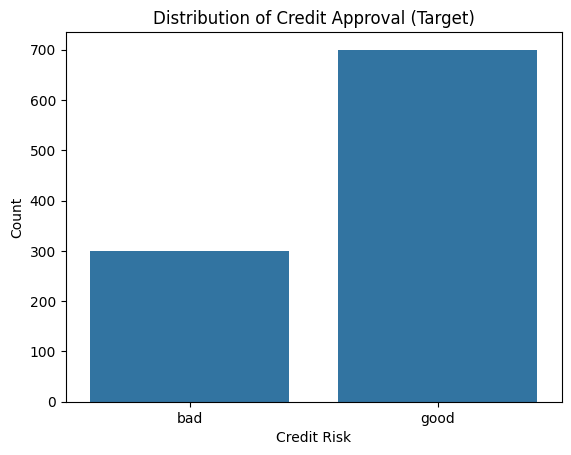

<ipython-input-4-06c6a1da8988>:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


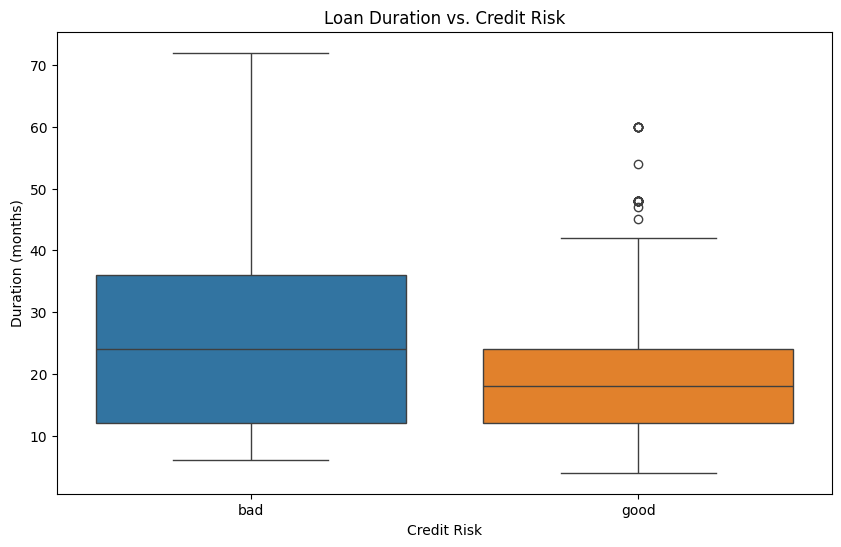

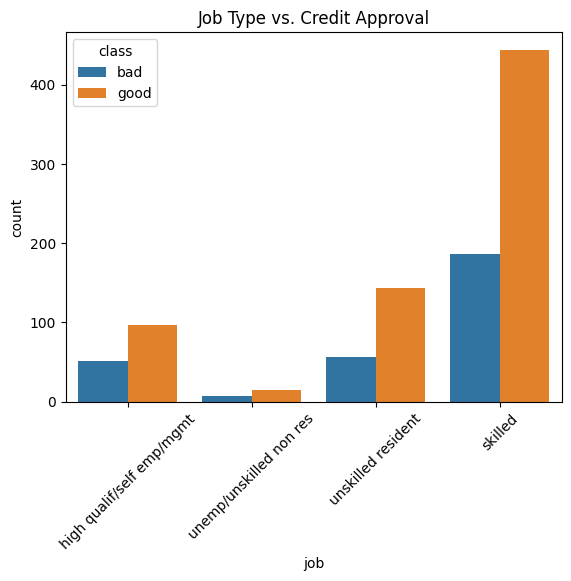

In [4]:
# 2. Create at least 3 visualizations to understand trends in the dataset.
# Plot 1: Distribution of Target Variable / Target Distribution (Bar Plot)
# Purpose: Shows imbalance between "good" and "bad" credit ratings.
sns.countplot(x="class", data=df)
plt.title("Distribution of Credit Approval (Target)")
plt.xlabel('Credit Risk')
plt.ylabel('Count')
plt.show()

# Plot 2: Numerical Feature - Duration vs. Target (Boxplot)
# Purpose: Reveals if higher loan durations correlate with bad credit.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='class', y='duration', hue='class')
plt.title('Loan Duration vs. Credit Risk')
plt.xlabel('Credit Risk')
plt.ylabel('Duration (months)')
plt.legend().remove()
plt.show()

# Plot 3: Categorical Feature - Job vs. Target
# Purpose: Certain jobs (e.g., "skilled") have higher approval rates.
sns.countplot(x="job", hue="class", data=df)
plt.xticks(rotation=45)
plt.title("Job Type vs. Credit Approval")
plt.show()

# 3. Answer at least three key questions about the data (e.g., trends, correlations, distributions).
# A: The Purpose of each?

### Part 3: Data Cleaning & Feature Engineering (10 points)
1. Handle missing values appropriately and justify your approach.
2. Create at least one new feature from existing data (feature engineering).
3. Normalize or encode categorical features as needed.

In [5]:
# 1. Handle missing values appropriately and justify your approach.
# As visualized in the previous program, the data doesn't have missing values
#Identify duplicates
print("Duplicated Values:", df.duplicated().sum(), "\n")

# 2. Create at least one new feature from existing data (feature engineering).
df['debt_to_income'] = df['credit_amount'] / (df['installment_commitment'] * df['duration'])
df['debt_to_income']

Duplicated Values: 0 



,debt_to_income
0,48.708333
1,61.989583
2,87.333333
3,93.833333
4,67.638889
...,...
995,48.222222
996,32.141667
997,16.750000
998,10.250000


In [6]:
# 3. Normalize or encode categorical features as needed.
#    Normalize numerical features? Optional (depends on the model).
#    Encode categorical features? Yes (ordinal + one-hot).

# Convert target to binary (good=1, bad=0)
y = (y == 'good').astype(int)

numerical_cols = X.select_dtypes(include='number').columns
categorical_cols = X.select_dtypes(include=['category', 'object']).columns
print("Numerical features:", numerical_cols.tolist())
print("Categorical features:", categorical_cols)

# Preprocess numerical features
scaler = StandardScaler()

# Preprocess categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
label_encoder = LabelEncoder()

# Combine into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, numerical_cols),
        ("cat", ohe, categorical_cols),
    ]
)

Numerical features: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical features: Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object')


### Part 4: Modeling (20 points)
1. Define a clear prediction goal (e.g., classification or regression).
2. Train at least three diferent models, use 5-fold cross-validation to evaluate model
performance.
3. Compare models using appropriate metrics (e.g., accuracy, RMSE, precision-recall,
or ROC curve).
4. Build an ensemble model and compare its performance.


→ Logistic Regression:
5-Fold Cross-validation Scores: [79.5 76.  72.  74.  73. ]
5-fold CV Mean: 74.90%
Mean Confusion Matrix:
[[ 28  31]
 [ 18 121]]
5-fold CV Accuracy: 74.90%
5-fold CV Precision: 70.00%
5-fold CV Recall: 67.09%
5-fold CV f1_score: 67.98%
5-fold CV AUC: 78.03% 


→ SVM:
5-Fold Cross-validation Scores: [79.  75.5 72.5 75.5 80. ]
5-fold CV Mean: 76.50%
Mean Confusion Matrix:
[[ 23  37]
 [ 10 130]]
5-fold CV Accuracy: 76.50%
5-fold CV Precision: 73.73%
5-fold CV Recall: 65.54%
5-fold CV f1_score: 66.97%
5-fold CV AUC: 78.96% 


→ Naïve Bayes:
5-Fold Cross-validation Scores: [71.5 71.5 50.  67.5 72.5]
5-fold CV Mean: 66.60%
Mean Confusion Matrix:
[[43 16]
 [50 89]]
5-fold CV Accuracy: 66.60%
5-fold CV Precision: 66.48%
5-fold CV Recall: 67.99%
5-fold CV f1_score: 63.89%
5-fold CV AUC: 73.61% 


→ Random Forest:
5-Fold Cross-validation Scores: [75.5 77.5 71.  75.5 76. ]
5-fold CV Mean: 75.10%
Mean Confusion Matrix:
[[ 24  36]
 [ 11 129]]
5-fold CV Accuracy: 75.10%
5-fold

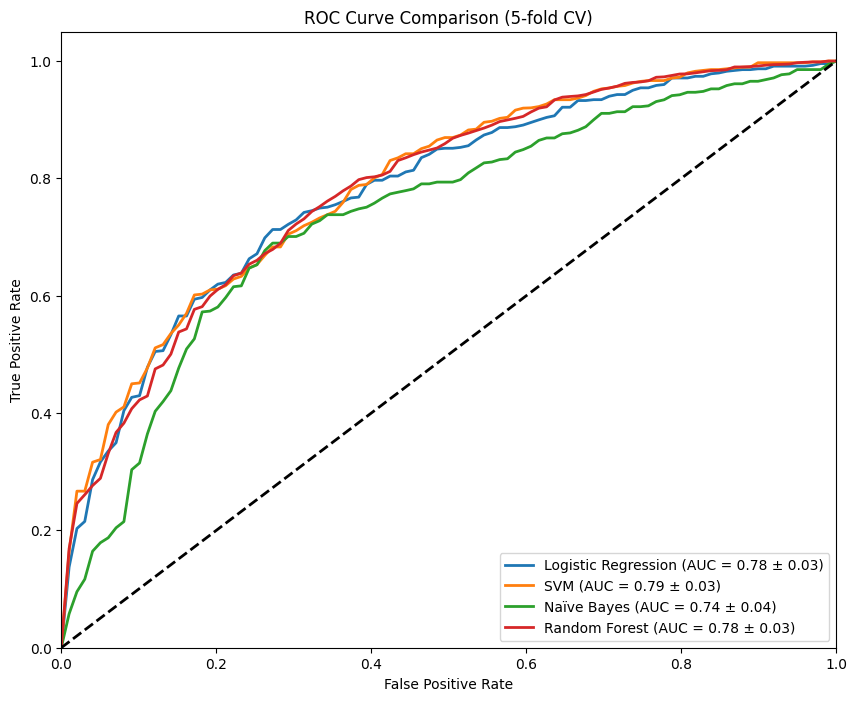

In [7]:
# Define the models
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "Naïve Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier()
}

# Initialize an empty list to store all model results
results = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Plot the ROC curves
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Initialize variables for confusion matrix
    all_cm = []

    # Initialize variables for ROC curve
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    print(f'\n→ {name}:')

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X.loc[train_idx].copy(), X.loc[test_idx].copy()
        y_train, y_test = y.loc[train_idx].copy(), y.loc[test_idx].copy()

         # Create pipeline with preprocessing and model
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', clone(model))
        ])

        pipeline.fit(X_train, y_train)

        # Confusion Matrix calculation
        y_pred = pipeline.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        all_cm.append(cm)

        # ROC Curve calculation
        if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
            y_proba = pipeline.predict_proba(X_test)[:, 1]
        else:  # use decision function for models without predict_proba
            y_proba = pipeline.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

    # Calculate and print cross-validation scores
    scores = cross_val_score(Pipeline([('preprocessor', preprocessor), ('classifier', model)]), X, y, cv=kf) * 100
    cv_acurracy = cross_val_score(Pipeline([('preprocessor', preprocessor), ('classifier', model)]), X, y, cv=kf, scoring='accuracy') * 100
    cv_precision = cross_val_score(Pipeline([('preprocessor', preprocessor), ('classifier', model)]), X, y, cv=kf, scoring='precision_macro') * 100
    cv_recall = cross_val_score(Pipeline([('preprocessor', preprocessor), ('classifier', model)]), X, y, cv=kf, scoring='recall_macro') * 100
    cv_F1 = cross_val_score(Pipeline([('preprocessor', preprocessor), ('classifier', model)]), X, y, cv=kf, scoring='f1_macro') * 100
    cv_roc_auc = cross_val_score(Pipeline([('preprocessor', preprocessor), ('classifier', model)]), X, y, cv=kf, scoring='roc_auc') * 100

    print(f'5-Fold Cross-validation Scores: {scores}')
    print(f"5-fold CV Mean: {scores.mean():.2f}%")
    # Calculate and print mean confusion matrix
    mean_cm = np.mean(all_cm, axis=0)
    print(f"Mean Confusion Matrix:")
    print(mean_cm.astype(int))
    print(f"5-fold CV Accuracy: {cv_acurracy.mean():.2f}%")
    print(f"5-fold CV Precision: {cv_precision.mean():.2f}%")
    print(f"5-fold CV Recall: {cv_recall.mean():.2f}%")
    print(f"5-fold CV f1_score: {cv_F1.mean():.2f}%")
    print(f"5-fold CV AUC: {cv_roc_auc.mean():.2f}% \n")

    results.append([
        name,
        cv_acurracy.mean(),
        cv_precision.mean(),
        cv_recall.mean(),
        cv_F1.mean(),
        cv_roc_auc.mean()
    ])

    # Plot mean ROC curve
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    plt.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {mean_auc:.2f} ± {std_auc:.2f})', lw=2)

# Create a DataFrame with model names as index
table = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "f1_score", "AUC-ROC"]
).set_index("Model")  # Set 'Model' as the index column

# Print the results
print(table)

# Customize the plot
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (5-fold CV)')
plt.legend(loc="lower right")
plt.show()